In [1]:
import pastas as ps

import hydropandas as hpd

In [2]:
hpd.util.get_color_logger("INFO")

<RootLogger root (INFO)>

In [3]:
## Lizard uses the organisation parameter to specify the data source.
organisation = "rotterdam"

# UNCOMMENT AND SET YOUR API KEY IF YOU NEED TO SPECIFY CREDENTIALS
your_api_key = "your_api_key_here"
auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [4]:
my_extent = (90_600, 91_047, 441_032, 441_272) # Rijksdriehoek (xmin, xmax, ymin, ymax)
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 2
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  2.16it/s]


In [5]:
oc.plots.interactive_map(
    color="red",
    zoom_start=15,
    tiles="Esri.WorldImagery",
    popup_width=350
)

In [6]:
oc

,x,y,location,filename,source,unit,tube_nr,screen_top,screen_bottom,ground_level,tube_top,metadata_available,obs,lat,lon
name,,,,,,,,,,,,,,,
GMW000000036741001,90998.687871,441239.318459,MEIJPL-12,,lizard,m NAP,1,-15.68,-16.68,-4.56,-2.68,True,GroundwaterObs GMW000000036741001 -----metadat...,51.955901,4.456115
GMW000000036989001,90664.868686,441145.728338,127572-1,,lizard,m NAP,1,-5.15,-7.15,-4.34,-4.35,True,GroundwaterObs GMW000000036989001 -----metadat...,51.955021,4.451277


In [7]:
oc.obs.values[0]

,GMW000000036741001
x,90998.687871
y,441239.318459
location,MEIJPL-12
filename,
source,lizard
unit,m NAP
tube_nr,1
screen_top,-15.68
screen_bottom,-16.68
ground_level,-4.56


INFO:hydropandas.extensions.plots.section_plot:created sectionplot -> GMW000000036741001
INFO:hydropandas.extensions.plots.section_plot:created sectionplot -> GMW000000036989001


(<Figure size 1500x500 with 2 Axes>,
 [<Axes: ylabel='m NAP'>, <Axes: ylabel='m NAP'>])

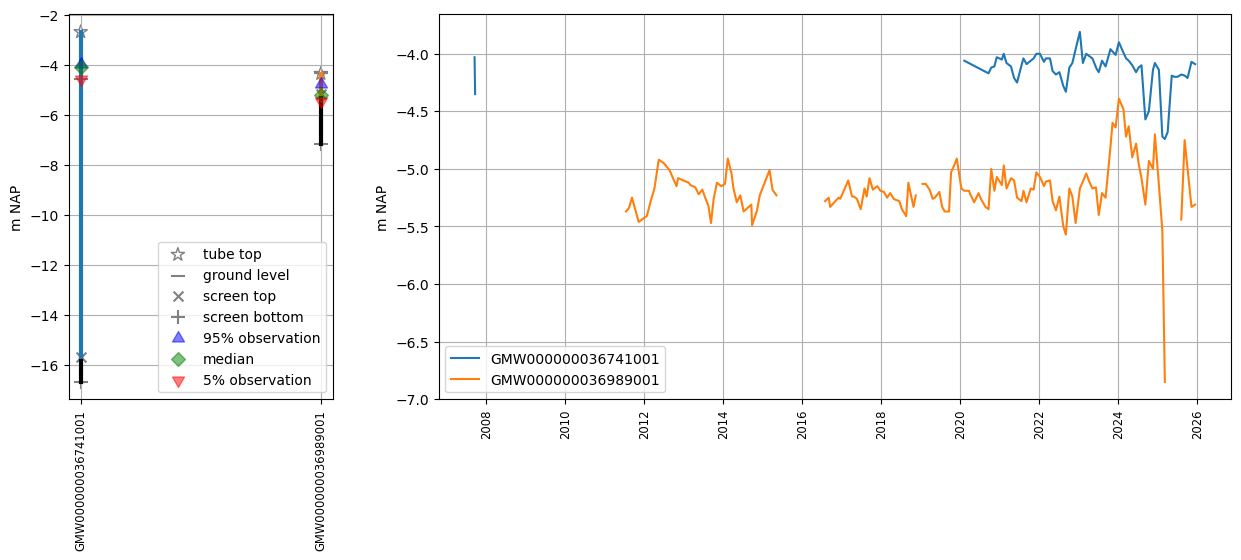

In [8]:
oc.plots.section_plot(plot_obs=True)

GroundwaterObs GMW000000036989001
-----metadata------
name : GMW000000036989001 
x : 90664.86868569531 
y : 441145.7283381047 
location : 127572-1 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -5.1499999999999995 
screen_bottom : -7.1499999999999995 
ground_level : -4.34 
tube_top : -4.35 
metadata_available : True 

-----time series------
                     value  flag        comment origin
peil_datum_tijd                                       
2011-07-14 23:00:00  -5.37   NaN        Gemeten   hand
2011-08-11 07:58:00  -5.34   NaN        Gemeten   hand
2011-09-08 09:37:00  -5.25   NaN        Gemeten   hand
2011-11-09 00:00:00  -5.46   NaN        Gemeten   hand
2012-01-23 10:53:00  -5.41   NaN        Gemeten   hand
...                    ...   ...            ...    ...
2025-03-31 09:09:00    NaN   NaN  niet te meten   hand
2025-08-04 12:05:56  -5.44   2.0        Gemeten   hand
2025-09-04 09:19:32  -4.75   2.0        Gemeten   hand
2025-11-06 15:05:05  -5.33  

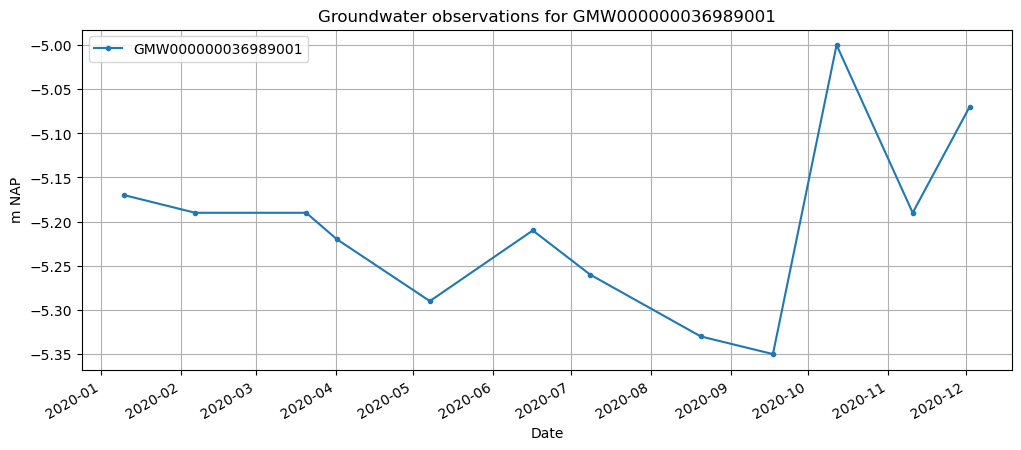

In [9]:
gw_lizard = oc.obs["GMW000000036989001"]
print(gw_lizard)

ax = gw_lizard["value"]["2020"].plot(
    figsize=(12, 5),
    marker=".",
    grid=True,
    label=gw_lizard.name,
    legend=True,
    xlabel="Date",
    ylabel="m NAP",
    title="Groundwater observations for " + gw_lizard.name,
)

In [10]:
print(gw_lizard["flag"].value_counts(normalize=True) * 100)
gw_lizard[gw_lizard["flag"] == "onbetrouwbaar"]

flag
2.0    100.0
Name: proportion, dtype: float64


,GMW000000036989001
x,90664.868686
y,441145.728338
location,127572-1
filename,
source,lizard
unit,m NAP
tube_nr,1
screen_top,-5.15
screen_bottom,-7.15
ground_level,-4.34


INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (90664.86868569531, 441145.7283381047) and meteovariable RH
INFO:hydropandas.io.knmi.fill_missing_measurements:knmi station De Bilt has no measurements for RH after 2025-12-09 01:00:00 and an end date of 2025-12-10 08:03:59 was requested. Changing end to 2025-12-09 01:00:00
INFO:hydropandas.io.knmi._add_missing_indices:station 344 has no measurements after 2025-12-09 01:00:00
INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (90664.86868569531, 441145.7283381047) and meteovariable EV24
INFO:hydropandas.io.knmi.fill_missing_measurements:knmi station De Bilt has no measurements for EV24 after 2025-12-09 01:00:00 and an end date of 2025-12-10 08:03:59 was requested. Changing end to 2025-12-09 01:00:00
INFO:hydropandas.io.knmi._add_missing_indices:station 344 has no measurements after 2025-12-09 01:00:00
INFO:pastas.timeseries._fill_nan:Time Series 'value': 10 nan-v

[<Axes: xlabel='peil_datum_tijd', ylabel='Head'>,
 <Axes: >,
 <Axes: title={'right': "Stresses: ['RH', 'EV24']"}, ylabel='Rise'>,
 <Axes: title={'center': 'Step response'}>,
 <Axes: title={'left': 'Model parameters ($n_c$=5)'}>]

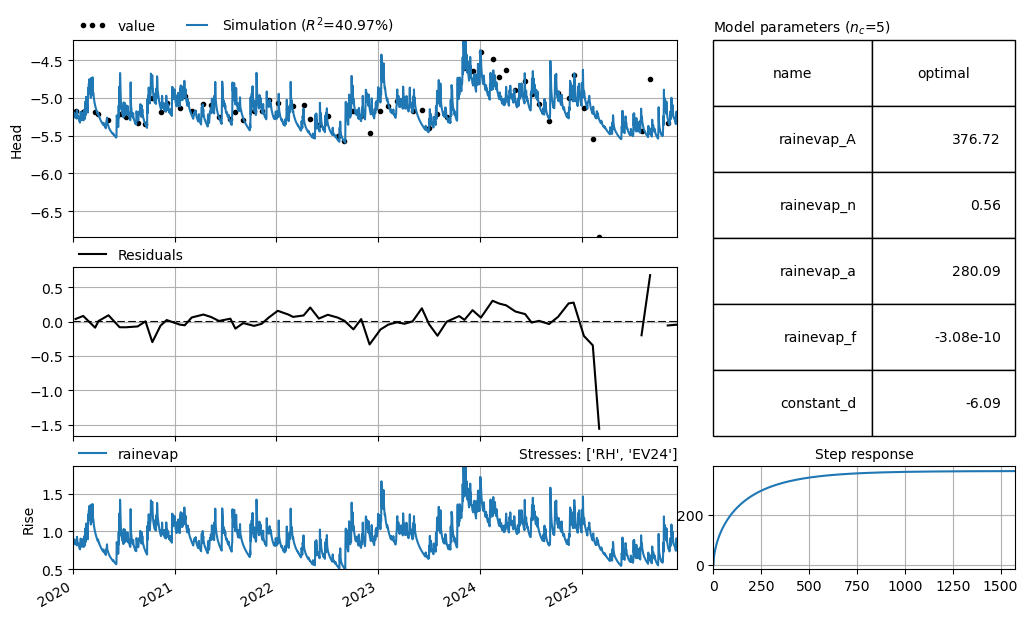

In [11]:
# Get the precipitation and evaporation data from the KNMI
precipitation = hpd.PrecipitationObs.from_knmi(
    xy=(gw_lizard.x, gw_lizard.y),
    start=gw_lizard.index[0],
    end=gw_lizard.index[-1],
    fill_missing_obs=True,
)
evaporation = hpd.EvaporationObs.from_knmi(
    xy=(gw_lizard.x, gw_lizard.y),
    meteo_var="EV24",
    start=gw_lizard.index[0],
    end=gw_lizard.index[-1],
    fill_missing_obs=True,
)

# Create a Pastas Model
ml = ps.Model(
    gw_lizard.loc[gw_lizard["origin"] == "hand", "value"], name=gw_lizard.name # databron (hand, diver, diver_validated)
)

# Add the recharge data as explanatory variable
ts1 = ps.RechargeModel(
    precipitation["RH"].resample("D").first(),
    evaporation["EV24"].resample("D").first(),
    ps.Gamma(),
    name="rainevap",
    settings=("prec", "evap"),
)

# Add the stressmodel to the model and solve for period after 2015
ml.add_stressmodel(ts1)
ml.solve(tmin="2020")
ml.plots.results(figsize=(10, 6))